# Análise Exploratória de Dados - `happyT` processado

Este notebook faz uma verificação simples das bases processadas de treino, validação e teste geradas pelo pré-processamento. O objetivo é conferir tamanhos, primeiras linhas, estatísticas rápidas e `describe` das features e do alvo transformado.

## 1. Carregamento dos dados processados

Nesta etapa, carregamos os arquivos `X_train`, `X_val`, `X_test`, `y_train`, `y_val` e `y_test` salvos em `data/processed/happyT`. As features j? est?o escaladas e o alvo `redshift` est? na escala original.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.6f}".format)

In [3]:
DATA_DIR = Path("..") / "data" / "processed" / "happyT"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(DATA_DIR / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

datasets = {
    "treino": (X_train, y_train),
    "validacao": (X_val, y_val),
    "teste": (X_test, y_test),
}

print("Bases carregadas com sucesso.")

Bases carregadas com sucesso.


## 2. Diferenças de tamanho entre treino, validação e teste

Aqui comparamos a quantidade de linhas e colunas em cada partição. O conjunto de teste é maior porque combina os splits externos B, C e D.

In [4]:
size_summary = []

for name, (X, y) in datasets.items():
    size_summary.append(
        {
            "base": name,
            "linhas_X": X.shape[0],
            "colunas_X": X.shape[1],
            "linhas_y": y.shape[0],
            "percentual_do_total": X.shape[0] / sum(data[0].shape[0] for data in datasets.values()),
        }
    )

size_summary = pd.DataFrame(size_summary)
size_summary["percentual_do_total"] = size_summary["percentual_do_total"] * 100

display(size_summary)

,base,linhas_X,colunas_X,linhas_y,percentual_do_total
0,treino,59960,10,59960,21.052853
1,validacao,14990,10,14990,5.263213
2,teste,209857,10,209857,73.683933


In [5]:
for name, (X, y) in datasets.items():
    display(Markdown(f"### Shape da base de {name}"))
    print(f"X_{name}: {X.shape[0]:,} linhas x {X.shape[1]:,} colunas")
    print(f"y_{name}: {y.shape[0]:,} linhas")

### Shape da base de treino

X_treino: 59,960 linhas x 10 colunas
y_treino: 59,960 linhas


### Shape da base de validacao

X_validacao: 14,990 linhas x 10 colunas
y_validacao: 14,990 linhas


### Shape da base de teste

X_teste: 209,857 linhas x 10 colunas
y_teste: 209,857 linhas


## 3. Primeiras linhas das bases processadas

Abaixo exibimos `head(10)` para cada partição. As colunas devem permanecer com os mesmos nomes das features originais, mas seus valores já estão transformados pelo pré-processamento.

In [ ]:
for name, (X, y) in datasets.items():
    display(Markdown(f"### X_{name} - head(10)"))
    display(X.head(10))

    display(Markdown(f"### y_{name} - head(10)"))
    display(y.head(10).to_frame(name="redshift"))


## 4. Estatísticas rápidas

Nesta seção, verificamos valores nulos, infinitos, médias e desvios das features processadas. Como as magnitudes passaram por `StandardScaler`, esperamos médias próximas de zero no treino. Os erros passaram por `log1p` e `RobustScaler`, então são avaliados em uma escala robusta.

In [ ]:
quick_stats = []

for name, (X, y) in datasets.items():
    numeric_values = X.to_numpy()
    quick_stats.append(
        {
            "base": name,
            "nulos_X": int(X.isna().sum().sum()),
            "nulos_y": int(y.isna().sum()),
            "infinitos_X": int(np.isinf(numeric_values).sum()),
            "media_geral_X": X.mean().mean(),
            "desvio_medio_X": X.std().mean(),
            "min_y": y.min(),
            "media_y": y.mean(),
            "max_y": y.max(),
        }
    )

quick_stats = pd.DataFrame(quick_stats)
display(quick_stats)


In [7]:
feature_mean_std = []

for name, (X, _) in datasets.items():
    stats = X.agg(["mean", "std"]).T.reset_index()
    stats.insert(0, "base", name)
    stats = stats.rename(columns={"index": "feature"})
    feature_mean_std.append(stats)

feature_mean_std = pd.concat(feature_mean_std, ignore_index=True)
display(feature_mean_std)

,base,feature,mean,std
0,treino,u,-0.000000,1.000008
1,treino,g,-0.000000,1.000008
2,treino,r,0.000000,1.000008
3,treino,i,0.000000,1.000008
4,treino,z,-0.000000,1.000008
5,treino,uErr,0.065699,0.569868
6,treino,gErr,0.211596,0.830225
7,treino,rErr,0.216072,0.921476
8,treino,iErr,0.199038,1.201549
9,treino,zErr,0.233620,1.260135


## 5. Describe das features processadas

O `describe` mostra a distribuição das features depois das transformações. Essa etapa ajuda a confirmar se treino, validação e teste estão em escalas compatíveis.

In [8]:
for name, (X, _) in datasets.items():
    display(Markdown(f"### Describe de X_{name}"))
    display(X.describe().T)

### Describe de X_treino

,count,mean,std,min,25%,50%,75%,max
u,63707.000000,-0.000000,1.000008,-4.418799,-0.875272,0.110686,0.745291,3.981957
g,63707.000000,-0.000000,1.000008,-4.790128,-0.946483,0.312524,0.839062,4.158732
r,63707.000000,0.000000,1.000008,-4.878810,-0.870272,0.188164,0.878054,5.366533
i,63707.000000,0.000000,1.000008,-5.255622,-0.818372,0.224281,0.851229,6.892994
z,63707.000000,-0.000000,1.000008,-5.107751,-0.793480,0.208394,0.820363,7.987910
uErr,63707.000000,0.065699,0.569868,-0.637170,-0.503715,0.000000,0.496285,4.528046
gErr,63707.000000,0.211596,0.830225,-0.549025,-0.416637,0.000000,0.583363,27.928769
rErr,63707.000000,0.216072,0.921476,-0.712337,-0.379389,0.000000,0.620611,38.249808
iErr,63707.000000,0.199038,1.201549,-1.158542,-0.430721,0.000000,0.569279,71.491573
zErr,63707.000000,0.233620,1.260135,-1.334457,-0.428323,0.000000,0.571677,41.122853


### Describe de X_validacao

,count,mean,std,min,25%,50%,75%,max
u,11243.000000,0.003927,1.003506,-4.345481,-0.873131,0.112467,0.748146,2.455114
g,11243.000000,-0.000285,0.998539,-4.159355,-0.940455,0.321648,0.838057,2.805251
r,11243.000000,-0.001406,0.996769,-4.304544,-0.860563,0.196023,0.874605,2.437825
i,11243.000000,0.001017,0.999596,-4.811747,-0.812070,0.234491,0.845677,4.167446
z,11243.000000,0.002077,0.997924,-4.992417,-0.787688,0.223882,0.817585,4.912155
uErr,11243.000000,0.065010,0.569944,-0.632149,-0.502239,-0.002920,0.496682,3.666036
gErr,11243.000000,0.206107,0.813010,-0.546153,-0.415471,-0.005319,0.577452,20.536753
rErr,11243.000000,0.200697,0.730462,-0.703284,-0.378408,-0.006338,0.618303,8.887925
iErr,11243.000000,0.195633,1.212649,-1.065422,-0.433944,0.002815,0.567085,66.506833
zErr,11243.000000,0.237929,1.320682,-1.331192,-0.433089,-0.000761,0.572218,42.273914


### Describe de X_teste

,count,mean,std,min,25%,50%,75%,max
u,209857.000000,0.256355,0.808516,-6.765669,-0.152613,0.305710,0.792145,3.640496
g,209857.000000,0.516647,0.881358,-6.320908,0.147425,0.740576,1.099313,5.967368
r,209857.000000,0.703452,0.970456,-6.189804,0.234804,0.932097,1.392860,6.885113
i,209857.000000,0.924279,1.132987,-6.180221,0.357853,1.067825,1.697403,9.695771
z,209857.000000,0.986105,1.194241,-5.810573,0.368696,1.087588,1.758327,8.017416
uErr,209857.000000,0.110815,0.482048,-0.635792,-0.273025,0.073034,0.447096,13.354468
gErr,209857.000000,0.503204,1.013452,-0.550139,-0.205748,0.296732,0.877246,52.664024
rErr,209857.000000,0.743487,1.181414,-0.717675,-0.126194,0.504479,1.307225,62.699823
iErr,209857.000000,1.362898,2.525916,-1.351902,-0.094769,0.669020,1.880077,114.530166
zErr,209857.000000,1.717934,2.919793,-1.398963,-0.087252,0.746639,2.292616,71.557201


## 6. Describe do alvo

O alvo salvo permanece na escala original de `redshift`, sem transforma??o `log1p`.

In [ ]:
for name, (_, y) in datasets.items():
    display(Markdown(f"### Describe de y_{name}"))
    display(y.to_frame(name="redshift").describe().T)


## 7. Conferência das colunas

Por fim, confirmamos que as partições possuem o mesmo conjunto de features e que variáveis como `id`, `redshift` e `redshiftErr` não aparecem em `X`.

In [10]:
columns_summary = pd.DataFrame(
    {
        "X_train": X_train.columns,
        "X_val": X_val.columns,
        "X_test": X_test.columns,
    }
)

same_columns = list(X_train.columns) == list(X_val.columns) == list(X_test.columns)
forbidden_columns = {"id", "redshift", "redshiftErr"}
forbidden_present = forbidden_columns.intersection(X_train.columns)

print(f"Mesmas colunas em treino, validacao e teste: {same_columns}")
print(f"Colunas proibidas presentes em X_train: {sorted(forbidden_present)}")
display(columns_summary)

Mesmas colunas em treino, validacao e teste: True
Colunas proibidas presentes em X_train: []


,X_train,X_val,X_test
0,u,u,u
1,g,g,g
2,r,r,r
3,i,i,i
4,z,z,z
5,uErr,uErr,uErr
6,gErr,gErr,gErr
7,rErr,rErr,rErr
8,iErr,iErr,iErr
9,zErr,zErr,zErr


## 8. Distribuicoes do conjunto de teste

Nesta secao olhamos apenas para `X_test` e `y_test`, ou seja, a particao reservada para avaliacao final. O objetivo e conferir como as features processadas e o alvo se distribuem no teste.

O zoom abaixo e somente visual: os graficos limitados cortam apenas a cauda superior em p99, sem remover dados do dataframe.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

test_mag_cols = [col for col in ["u", "g", "r", "i", "z"] if col in X_test.columns]
test_err_cols = [col for col in ["uErr", "gErr", "rErr", "iErr", "zErr"] if col in X_test.columns]


def plot_test_histograms(cols, title, color="#2a6f97", zoom=False):
    n_cols = 3
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        values = X_test[col].dropna()
        subtitle = col

        if zoom:
            upper = values.quantile(0.99) # calcula o percentil 99%
            values = values[values <= upper]
            subtitle = f"{col} | ate p99"

        sns.histplot(values, bins=60, kde=True, ax=ax, color=color) # histplot para melhor visualização, especialmente com zoom
        ax.set_title(subtitle)
        ax.set_xlabel(col)
        ax.set_ylabel("contagem")

    for ax in axes[len(cols):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


### 8.1 Distribuicoes completas das features no teste

Primeiro, vemos a distribuicao completa das magnitudes e dos erros fotometricos ja processados. Como essas variaveis passaram pelo pipeline de preprocessamento, aqui o foco e conferir a forma geral das features que realmente entram nos modelos.

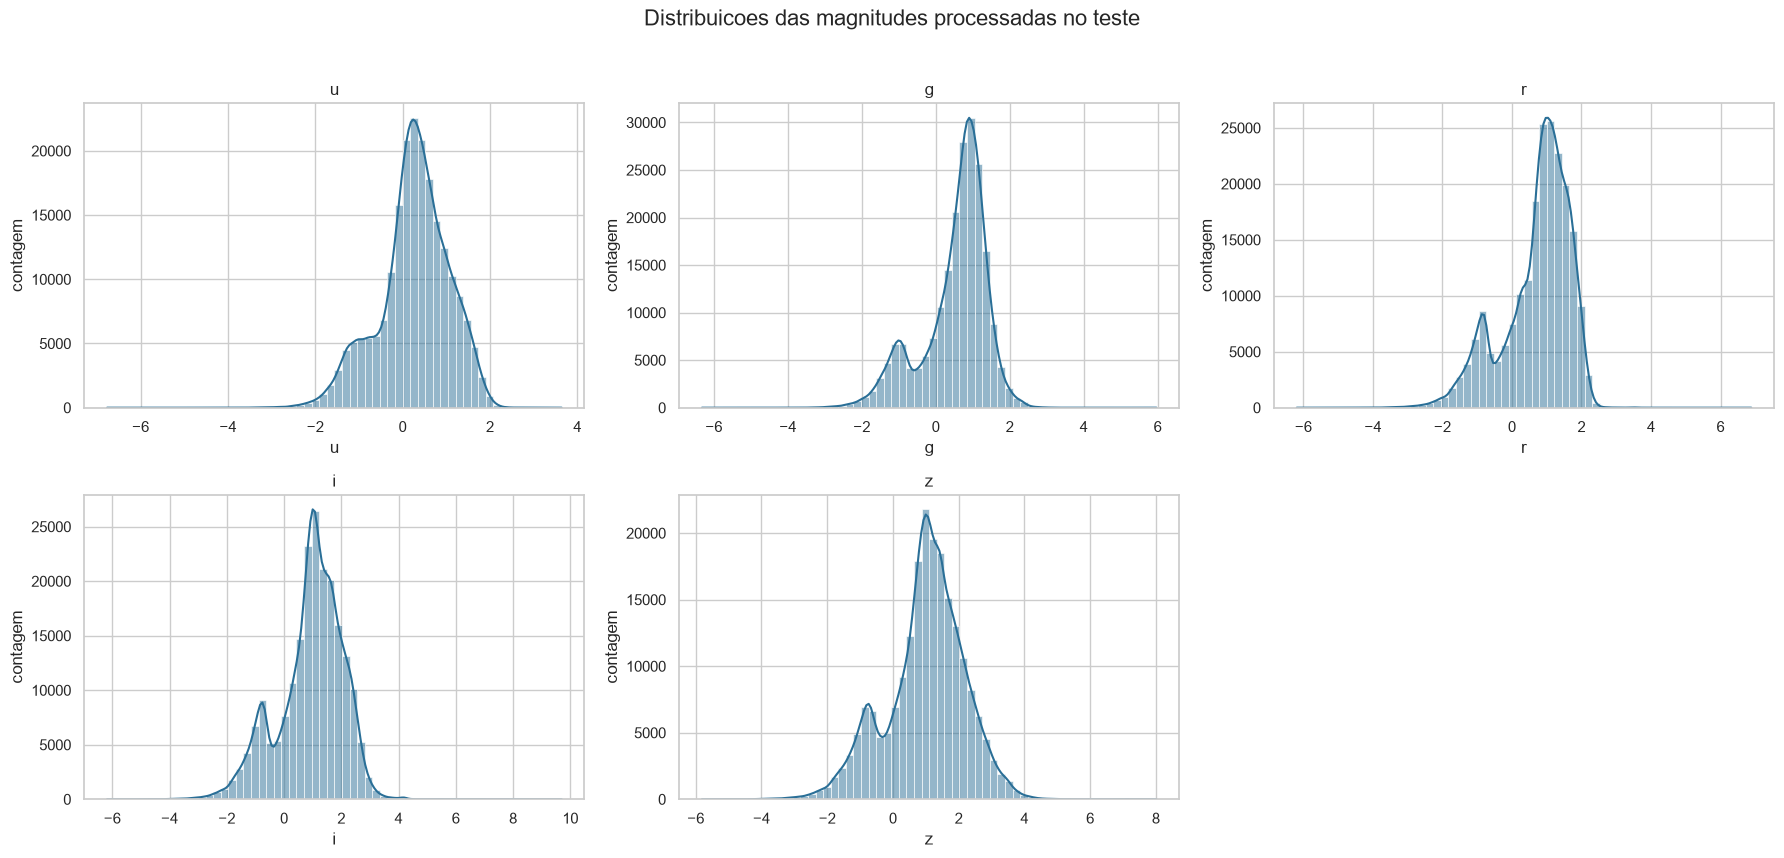

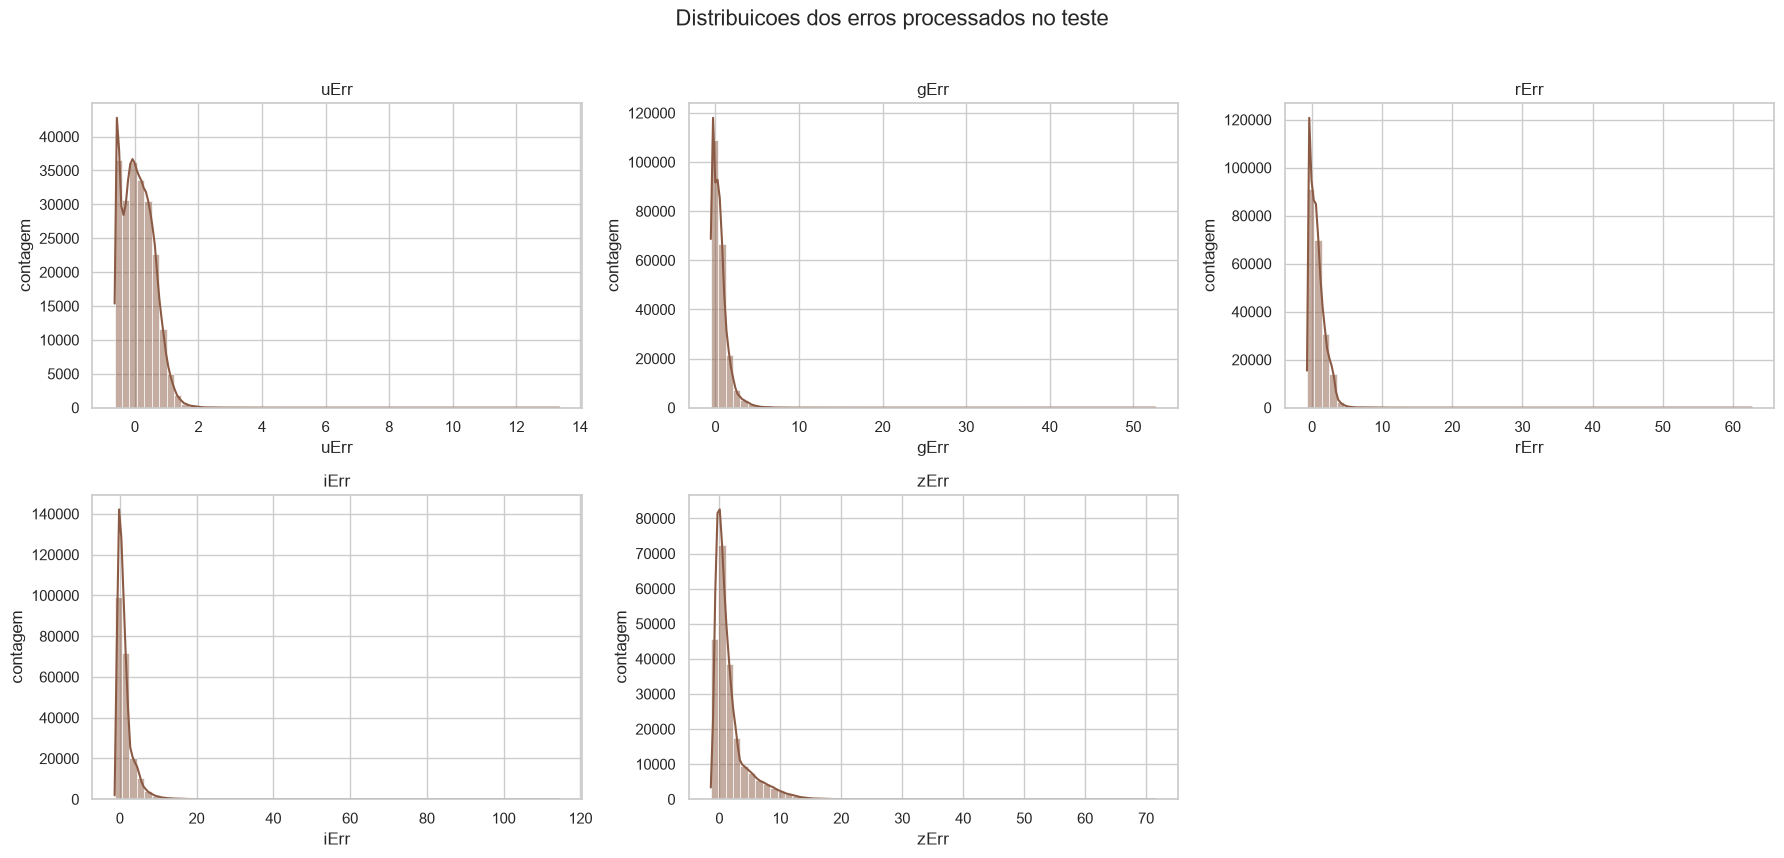

In [20]:
plot_test_histograms(
    test_mag_cols,
    "Distribuicoes das magnitudes processadas no teste",
    color="#2a6f97",
)

plot_test_histograms(
    test_err_cols,
    "Distribuicoes dos erros processados no teste",
    color="#8a5a44",
)


### 8.2 Zoom leve das features "Erros de Magnitudes" no teste

Agora repetimos os histogramas para os Erros de Magnitudes com um zoom visual ate p99. Esse recorte ajuda a comparar melhor a concentracao principal dos valores quando existem poucos pontos muito altos.

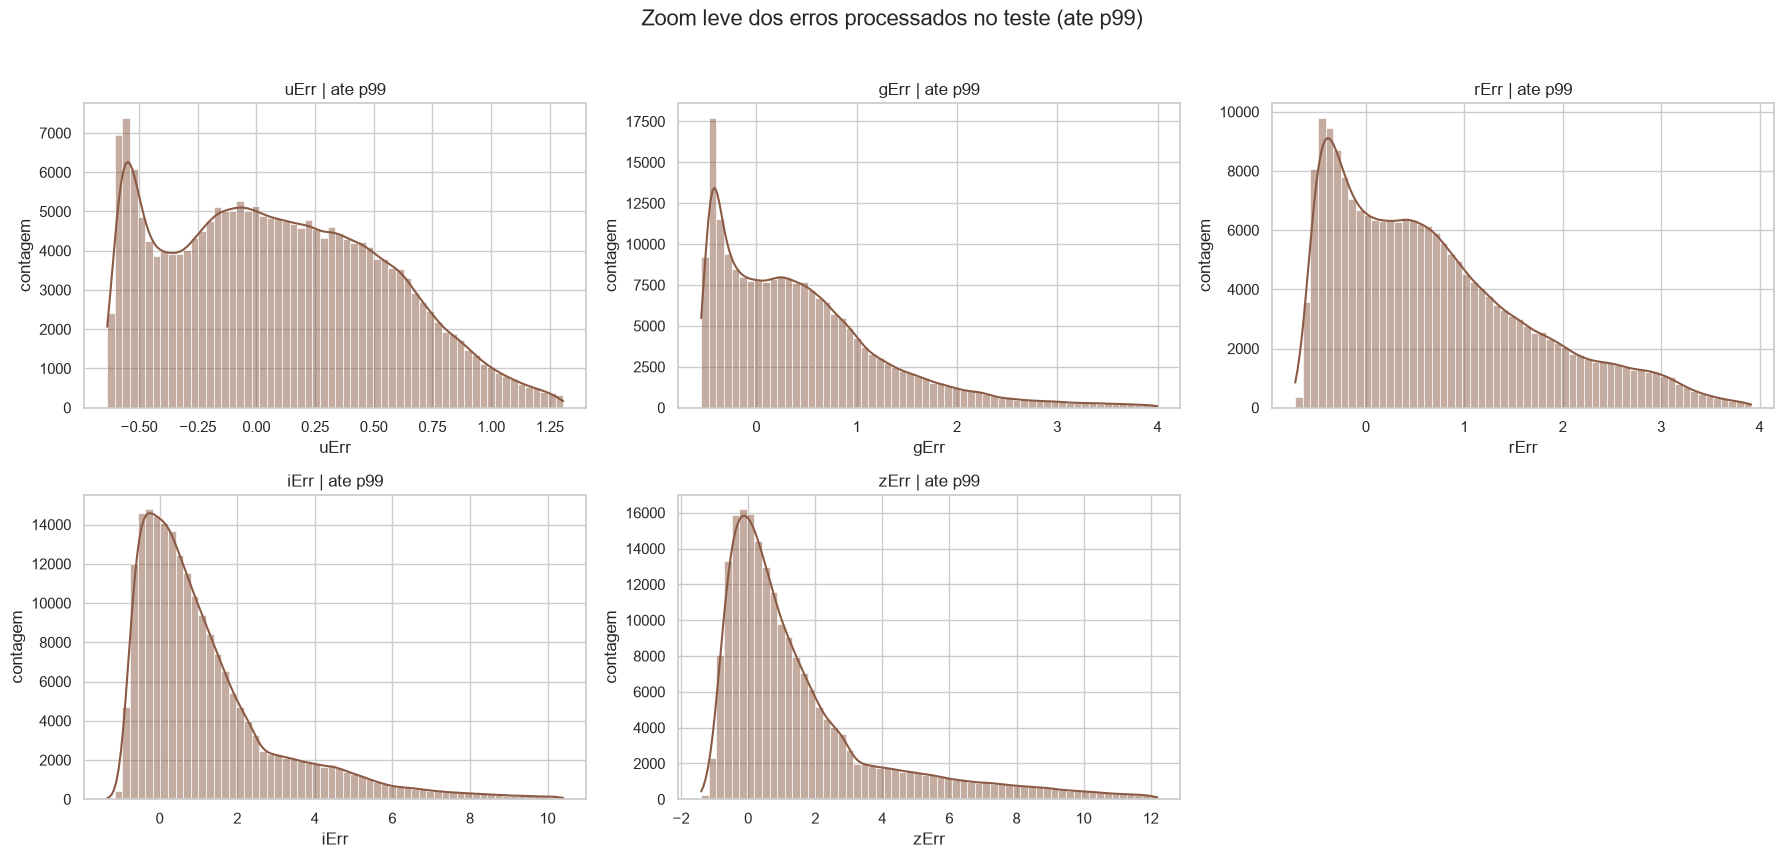

In [21]:

plot_test_histograms(
    test_err_cols,
    "Zoom leve dos erros processados no teste (ate p99)",
    color="#8a5a44",
    zoom=True,
)


### 8.3 Distribuicao do alvo no teste

O alvo em `y_test` esta salvo diretamente na escala original de `redshift`.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.histplot(y_test, bins=60, kde=True, ax=ax, color="#2a6f97")
ax.set_title("Distribuicao de y_test em redshift")
ax.set_xlabel("redshift")
ax.set_ylabel("contagem")

plt.tight_layout()
plt.show()


### 8.4 Zoom da distribuicao do alvo no teste

Agora repetimos o histograma do alvo com um zoom visual ate p99 para observar melhor a regiao central da distribuicao.

In [ ]:
upper = y_test.quantile(0.99)
y_test_zoom = y_test[y_test <= upper]

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.histplot(y_test_zoom, bins=60, kde=True, ax=ax, color="#2a6f97")
ax.set_title("Distribuicao de y_test em redshift (ate p99)")
ax.set_xlabel("redshift")
ax.set_ylabel("contagem")

plt.tight_layout()
plt.show()
